## Comparison of ESA CCI Snow LAC and GAC data
#### Using values processed with lac_gac.py
#### Author: Elias Frey, RSGB/Unibe, 25.06.2024

### Import statements

In [1]:
import os
import warnings
import csv
import glob
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

### Functions

In [2]:
def get_coords():
    """
    Get region name and coordinate
    """
    coords_dict = {
        'usa_Alaska': [66.16, -153.37],                # Gates of the Arctic National Park, forest
        'can_Auyuittuq': [67.5, -65],                 # Auyuittuq National Park, mountains
        'chl_Rafael': [-46.76, -73,55],           # Parque Nacional Laguna San Rafael, glacier
        'nor_Jotunheim': [61.68, 7.03],           # Glacier
        'rus_Karelia': [61.82, 33.24],           # agriculture, forest
        'rus_Siberia': [63.32, 115.21],         # forest
    }

    return coords_dict

In [3]:
def get_csv_path(csv_main_dir, region):
    """
    Get csv file from directory
    """
    csv_file = glob.glob(os.path.join(path_to_csv_files, f"{region}*.csv"))[0]
    return csv_file

In [4]:
def get_csv_file(filename):
    """
    Get path of csv file for single plotting
    """
    csv_path = f'csv/{filename.split("_")[3]}_{filename.split("_")[4]}/{filename}.csv'
    return csv_path

In [5]:
def read_csv(csv_path):
    """
    Read csv file
    """
    # Initialize empty dictionary to store data
    csv_dict = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list))))
    
    # Read data from CSV file and populate dictionary
    with open(csv_path, 'r', newline='') as csv_file:
        reader = csv.DictReader(csv_file)
        for row in reader:
            date_str = row['date']
            platform = row['datatype']
            satellite = row['satellite']
            region = row['region']
            data_str = row['data']
            
            # Convert date string to datetime object
            date = datetime.strptime(date_str, '%Y%m%d').strftime('%d-%m-%Y')
            
            # Convert data string to list of floats, handling NaN values
            data = [np.nan if val == 'nan' else float(val) for val in data_str.strip('[]').split(',')]
            
            # Update dictionary
            csv_dict[date][platform][satellite][region] = data

    return csv_dict

In [6]:
def filter_dates(data, start_date, end_date, date_format="%d-%m-%Y"):
    """
    Filters the data dictionary to include only entries within the specified date range
    """
    start = datetime.strptime(start_date, date_format)
    end = datetime.strptime(end_date, date_format)

    filtered_data = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list))))

    for date_str, value in data.items():
        date = datetime.strptime(date_str, date_format)
        if start <= date <= end:
            filtered_data[date_str] = value

    return filtered_data

In [7]:
def get_regionstring(csv_path):
    country, region = os.path.basename(csv_path).split('_')[0:2]
    plot_title = f"{region.capitalize()} ({country.upper()})"
    return plot_title

In [8]:
def plot_comparison(var_dict, csv_path, plot_category, date_range):
    """
    Plot monthly mean comparison of LAC and GAC
    """
    warnings.filterwarnings(
        "ignore",
        category=RuntimeWarning,
        message="All-NaN axis encountered"
    )

    #Calculate monthly means
    monthly_data = {}

    for date, data in var_dict.items():
        # Assuming date is datetime-like
        month = date.to_period('M') if hasattr(date, 'to_period') else pd.to_datetime(date).to_period('M')

        if month not in monthly_data:
            monthly_data[month] = {
                'lac_noaa11': [],
                'gac_noaa11': [],
                'lac_noaa14': [],
                'gac_noaa14': []
            }

        for platform, platform_data in data.items():
            for satellite, satellite_data in platform_data.items():
                for region, region_data in satellite_data.items():
                    if region_data:
                        max_value = np.nanmax(region_data)

                        if not np.isnan(max_value):
                            key = f'{platform}_{satellite}'
                            if key in monthly_data[month]:
                                monthly_data[month][key].append(max_value)

    #Calculate mean for each month
    x = sorted(monthly_data.keys())

    lac_noaa11_y = []
    gac_noaa11_y = []
    lac_noaa14_y = []
    gac_noaa14_y = []

    for month in x:
        for key, output in [
            ('lac_noaa11', lac_noaa11_y),
            ('gac_noaa11', gac_noaa11_y),
            ('lac_noaa14', lac_noaa14_y),
            ('gac_noaa14', gac_noaa14_y)
        ]:
            values = monthly_data[month][key]

            if values:
                mean_value = np.nanmean(values)

                if plot_category:
                    mean_value = int(mean_value / 10) * 10

                output.append(mean_value)
            else:
                output.append(np.nan)

    # Convert Periods to strings for plotting
    x_labels = [str(month) for month in x]

    plt.figure(figsize=(10, 6))

    # Plot lines only for satellite category containing data
    if not all(np.isnan(lac_noaa11_y)):
        plt.scatter(
            x_labels, lac_noaa11_y,
            label='LAC NOAA11', marker='o', linestyle='-', color='#38b000'
        )

    if not all(np.isnan(lac_noaa14_y)):
        plt.scatter(
            x_labels, lac_noaa14_y,
            label='LAC NOAA14', marker='o', linestyle='-', color='#31572c'
        )

    if not all(np.isnan(gac_noaa11_y)):
        plt.scatter(
            x_labels, gac_noaa11_y,
            label='GAC NOAA11', marker='o', linestyle='-', color='#ffdd00'
        )

    if not all(np.isnan(gac_noaa14_y)):
        plt.scatter(
            x_labels, gac_noaa14_y,
            label='GAC NOAA14', marker='o', linestyle='-', color='#ffb703'
        )

    plt.xlabel('Month')
    plt.ylabel('Snow Cover Fraction [%]')

    csv_name = get_regionstring(csv_path)

    if plot_category:
        plt.title(
            f'Comparison of LAC & GAC SCFG (10-stage) '
            f'{csv_name} SCFG 0.15° × 0.15°'
        )
    else:
        plt.title(
            f'Comparison of LAC & GAC SCFG '
            f'{csv_name} SCFG 0.15° × 0.15°'
        )

    plt.legend()

    # Show at most ~10 x-axis labels
    plt.xticks(
        np.arange(0, len(x_labels), step=max(len(x_labels) // 10, 1)),
        rotation=45
    )

    plt.tight_layout()
    plt.grid(False)

    plt.savefig(
        f'plots/{date_range}/{csv_name}_SCFG_comparison_015x015_degree_{date_range}_monthly.png'
    )

    plt.show()

In [9]:
def plot_difference(var_dict, csv_path, date_range):
    """
    Plot monthly mean differences of LAC and GAC
    """
    warnings.filterwarnings(
        "ignore",
        category=RuntimeWarning,
        message="All-NaN axis encountered"
    )

    # Create monthly containers
    monthly_data = {}

    for date, data in var_dict.items():
        month = pd.to_datetime(date).to_period('M')

        if month not in monthly_data:
            monthly_data[month] = {
                'lac_noaa11': [],
                'gac_noaa11': [],
                'lac_noaa14': [],
                'gac_noaa14': []
            }

        for platform, platform_data in data.items():
            for satellite, satellite_data in platform_data.items():
                for region, region_data in satellite_data.items():
                    if region_data:
                        max_value = np.nanmax(region_data)

                        if not np.isnan(max_value):
                            category = int(max_value / 10) * 10
                            key = f'{platform}_{satellite}'

                            if key in monthly_data[month]:
                                monthly_data[month][key].append(category)

    # Calculate monthly means
    x = sorted(monthly_data.keys())

    lac_noaa11_y = []
    gac_noaa11_y = []
    lac_noaa14_y = []
    gac_noaa14_y = []

    for month in x:
        for key, output in [
            ('lac_noaa11', lac_noaa11_y),
            ('gac_noaa11', gac_noaa11_y),
            ('lac_noaa14', lac_noaa14_y),
            ('gac_noaa14', gac_noaa14_y)
        ]:
            values = monthly_data[month][key]

            if values:
                output.append(np.nanmean(values))
            else:
                output.append(np.nan)

    # Create arrays from lists
    arr1 = np.array(lac_noaa11_y)
    arr2 = np.array(gac_noaa11_y)
    arr3 = np.array(lac_noaa14_y)
    arr4 = np.array(gac_noaa14_y)

    # Calculate monthly differences
    differences1 = np.where(
        np.isnan(arr1) | np.isnan(arr2),
        np.nan,
        arr1 - arr2
    )

    differences2 = np.where(
        np.isnan(arr3) | np.isnan(arr4),
        np.nan,
        arr3 - arr4
    )

    # Find valid differences
    valid1 = ~np.isnan(differences1)
    valid2 = ~np.isnan(differences2)

    top10_diff1 = sorted(
        zip(np.array(x)[valid1], differences1[valid1]),
        key=lambda t: abs(t[1]),
        reverse=True
    )[:10]

    top10_diff2 = sorted(
        zip(np.array(x)[valid2], differences2[valid2]),
        key=lambda t: abs(t[1]),
        reverse=True
    )[:10]

    # Convert months to strings for plotting
    x_labels = [str(month) for month in x]

    # Plot monthly differences as scatter
    plt.figure(figsize=(10, 6))

    plt.scatter(
        x_labels,
        differences1,
        label='LAC-GAC NOAA11',
        marker='.',
        color='#0077b6'
    )

    plt.scatter(
        x_labels,
        differences2,
        label='LAC-GAC NOAA14',
        marker='.',
        color='#023e8a'
    )

    plt.xlabel('Month')
    plt.ylabel('Differences in Snow Cover Fraction [%]')

    csv_name = get_regionstring(csv_path)
    plt.title(
        f'Monthly Mean Differences of LAC - GAC SCFG '
        f'(10-step) {csv_name} SCFG 0.15° × 0.15°'
    )

    plt.legend()
    plt.xticks(
        np.arange(0, len(x_labels), step=max(len(x_labels)//10, 1)),
        rotation=45
    )
    plt.tight_layout()
    plt.grid(False)

    plt.savefig(
        f'plots/{date_range}/{csv_name}_SCFG_difference_015x015_degree_{date_range}_monthly.png'
    )
    plt.show()

    # Print the 10 largest monthly differences
    print(f"\nTop 10 NOAA11 monthly LAC-GAC differences for {csv_name}:")
    for date, diff in top10_diff1:
        print(f"{date}: {diff:.2f}")

    print(f"\nTop 10 NOAA14 monthly LAC-GAC differences for {csv_name}:")
    for date, diff in top10_diff2:
        print(f"{date}: {diff:.2f}")

    return top10_diff1, top10_diff2

### User input

In [10]:
### DEFINE PLOT PARAMETERS ###

# Csv file name
path_to_csv_files = 'csv/SCFG015x015_degree/'

# Range of Plot date
start_date = '01-01-1992'
end_date = '31-12-1996'

# Comparision plots
plot_category = False               # Categorize SCF values (10-stages)
fullrange_comparison = False        # Ignores start_date and end_date for comparison plots

# Differences plots
fullrange_differences = True        # Ignores start_date and end_date for difference plots

### Plotting

/tmp/ipykernel_292123/1139586768.py:16: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  month = date.to_period('M') if hasattr(date, 'to_period') else pd.to_datetime(date).to_period('M')


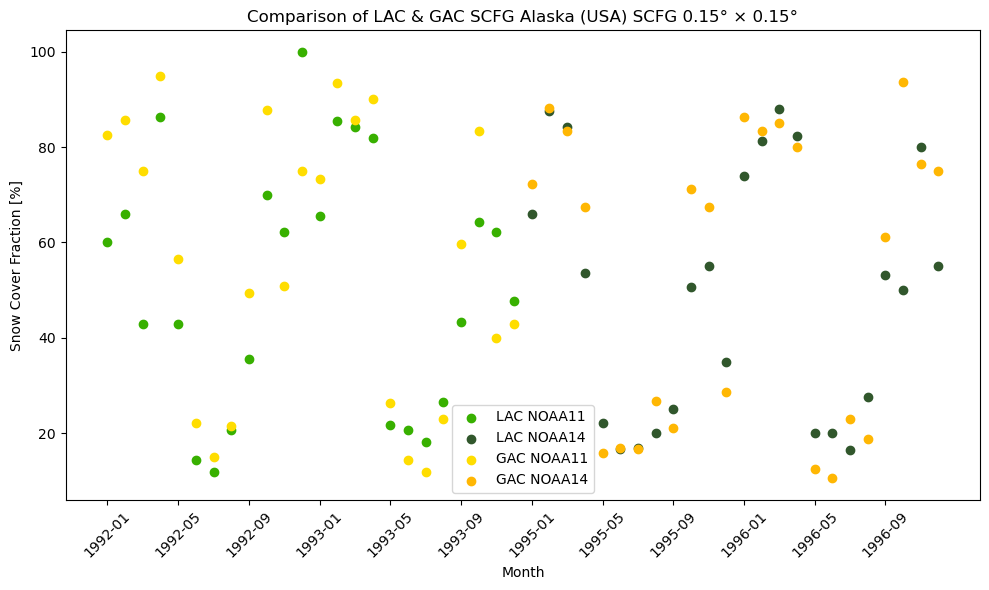

/tmp/ipykernel_292123/4266116972.py:15: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  month = pd.to_datetime(date).to_period('M')


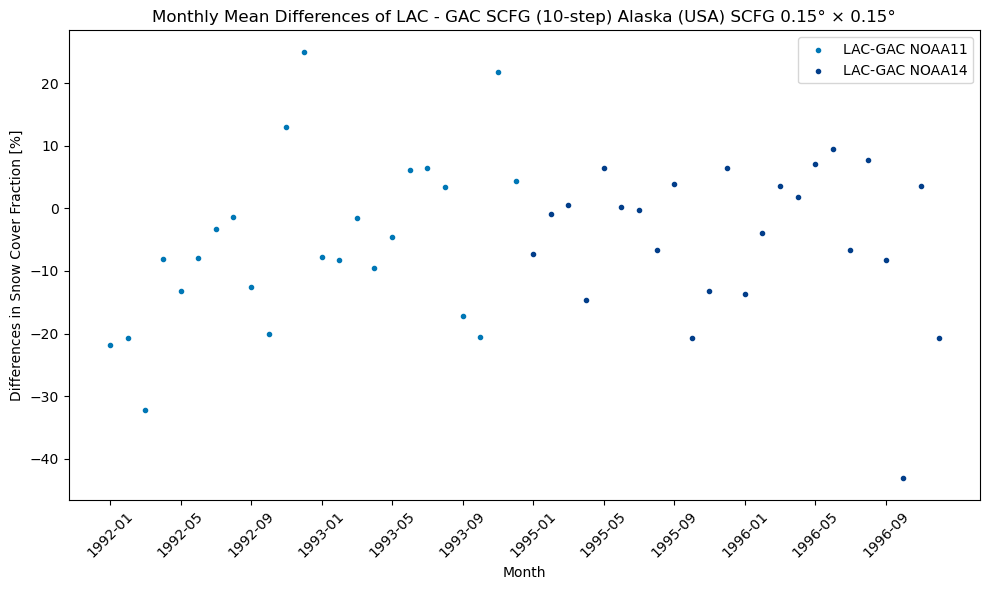


Top 10 NOAA11 monthly LAC-GAC differences for Alaska (USA):
1992-03: -32.14
1992-12: 25.00
1992-01: -21.90
1993-11: 21.82
1992-02: -20.71
1993-10: -20.61
1992-10: -20.03
1993-09: -17.12
1992-05: -13.25
1992-11: 12.97

Top 10 NOAA14 monthly LAC-GAC differences for Alaska (USA):
1996-10: -43.12
1996-12: -20.71
1995-10: -20.67
1995-04: -14.57
1996-01: -13.64
1995-11: -13.27
1996-06: 9.47
1996-09: -8.21
1996-08: 7.75
1995-01: -7.22


/tmp/ipykernel_292123/1139586768.py:16: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  month = date.to_period('M') if hasattr(date, 'to_period') else pd.to_datetime(date).to_period('M')


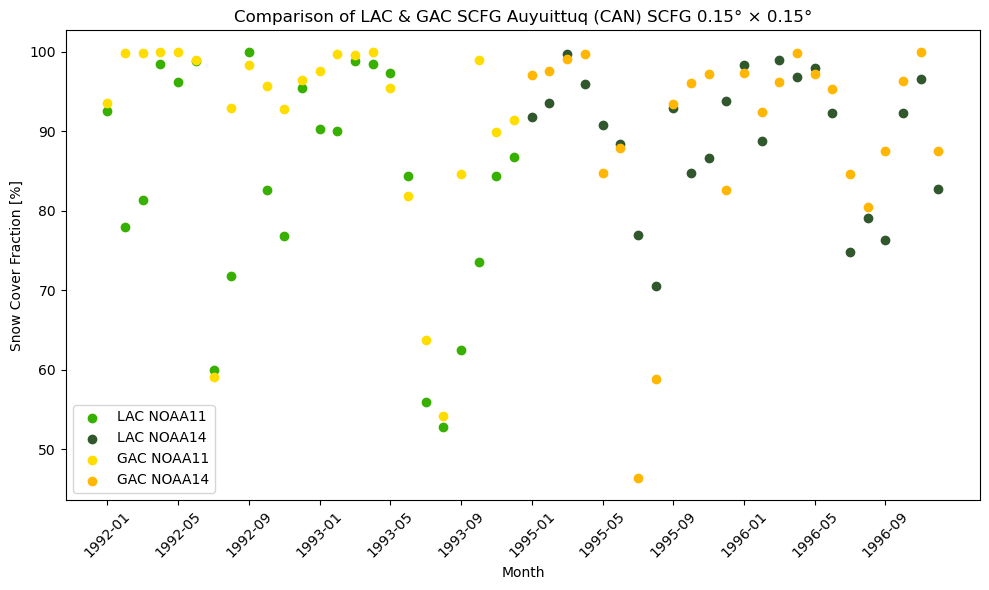

/tmp/ipykernel_292123/4266116972.py:15: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  month = pd.to_datetime(date).to_period('M')


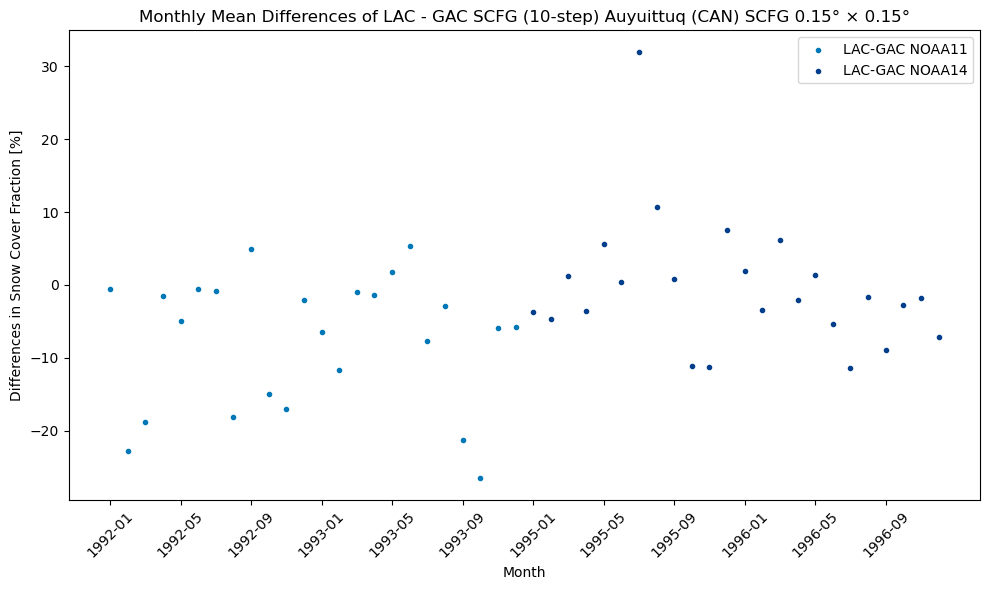


Top 10 NOAA11 monthly LAC-GAC differences for Auyuittuq (CAN):
1993-10: -26.53
1992-02: -22.81
1993-09: -21.25
1992-03: -18.80
1992-08: -18.06
1992-11: -17.00
1992-10: -15.00
1993-02: -11.71
1993-07: -7.67
1993-01: -6.51

Top 10 NOAA14 monthly LAC-GAC differences for Auyuittuq (CAN):
1995-07: 32.00
1996-07: -11.41
1995-11: -11.27
1995-10: -11.12
1995-08: 10.67
1996-09: -8.97
1995-12: 7.50
1996-12: -7.14
1996-03: 6.16
1995-05: 5.63


/tmp/ipykernel_292123/1139586768.py:16: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  month = date.to_period('M') if hasattr(date, 'to_period') else pd.to_datetime(date).to_period('M')


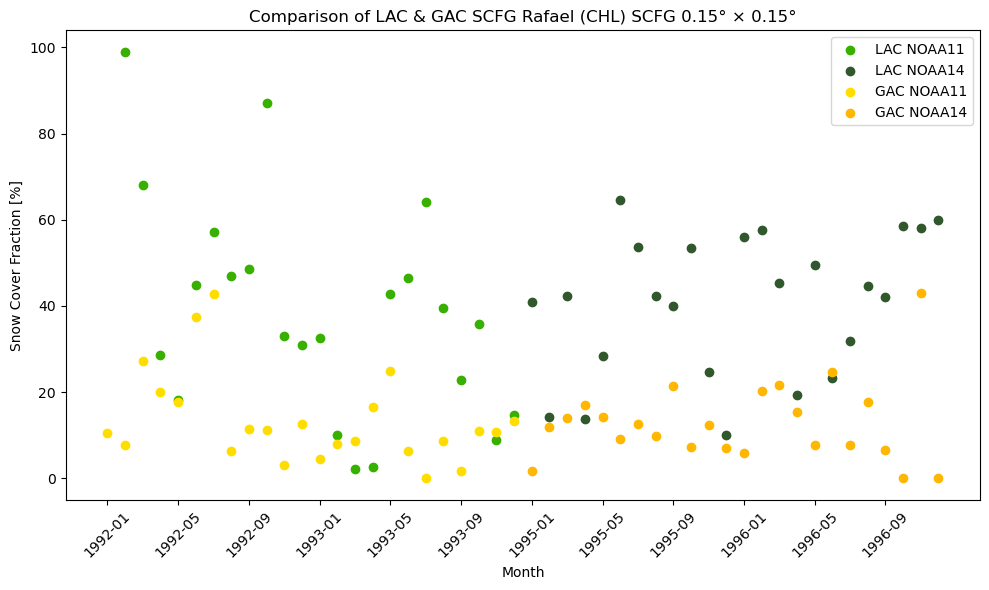

/tmp/ipykernel_292123/4266116972.py:15: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  month = pd.to_datetime(date).to_period('M')


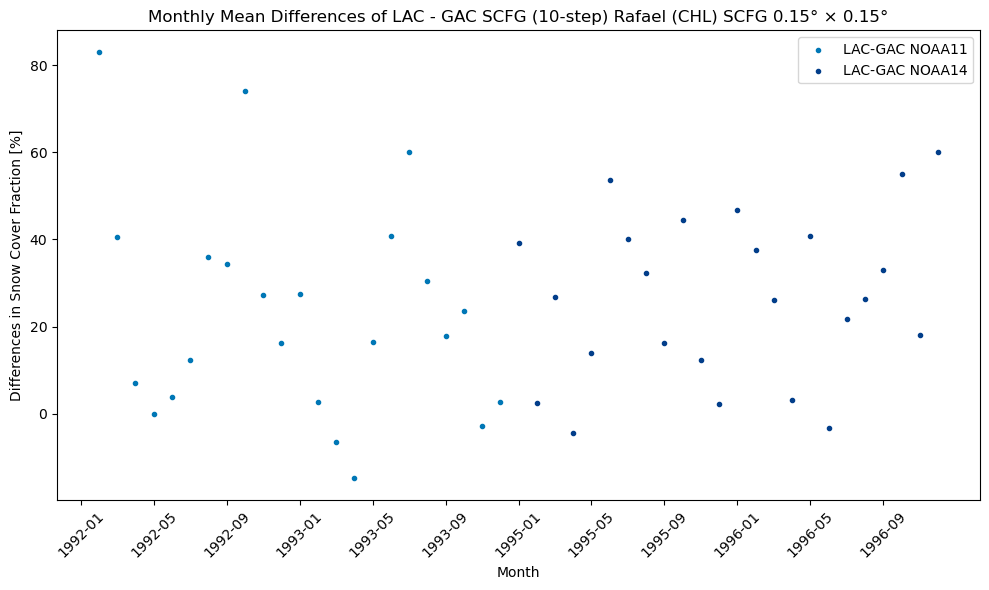


Top 10 NOAA11 monthly LAC-GAC differences for Rafael (CHL):
1992-02: 83.08
1992-10: 74.00
1993-07: 60.00
1993-06: 40.71
1992-03: 40.62
1992-08: 35.97
1992-09: 34.29
1993-08: 30.50
1993-01: 27.54
1992-11: 27.27

Top 10 NOAA14 monthly LAC-GAC differences for Rafael (CHL):
1996-12: 60.00
1996-10: 55.00
1995-06: 53.64
1996-01: 46.79
1995-10: 44.47
1996-05: 40.83
1995-07: 40.00
1995-01: 39.17
1996-02: 37.45
1996-09: 32.89


/tmp/ipykernel_292123/1139586768.py:16: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  month = date.to_period('M') if hasattr(date, 'to_period') else pd.to_datetime(date).to_period('M')


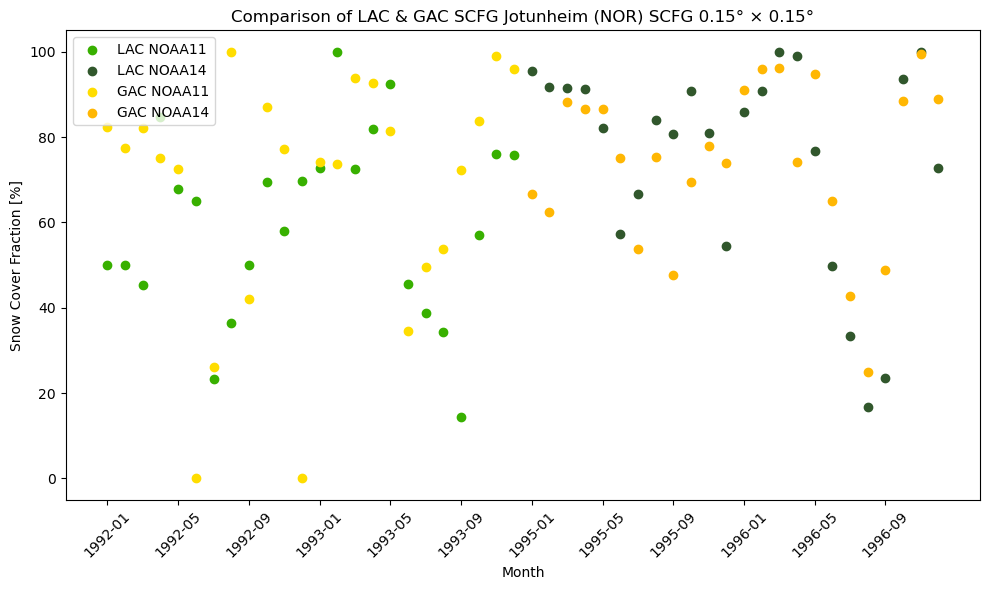

/tmp/ipykernel_292123/4266116972.py:15: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  month = pd.to_datetime(date).to_period('M')


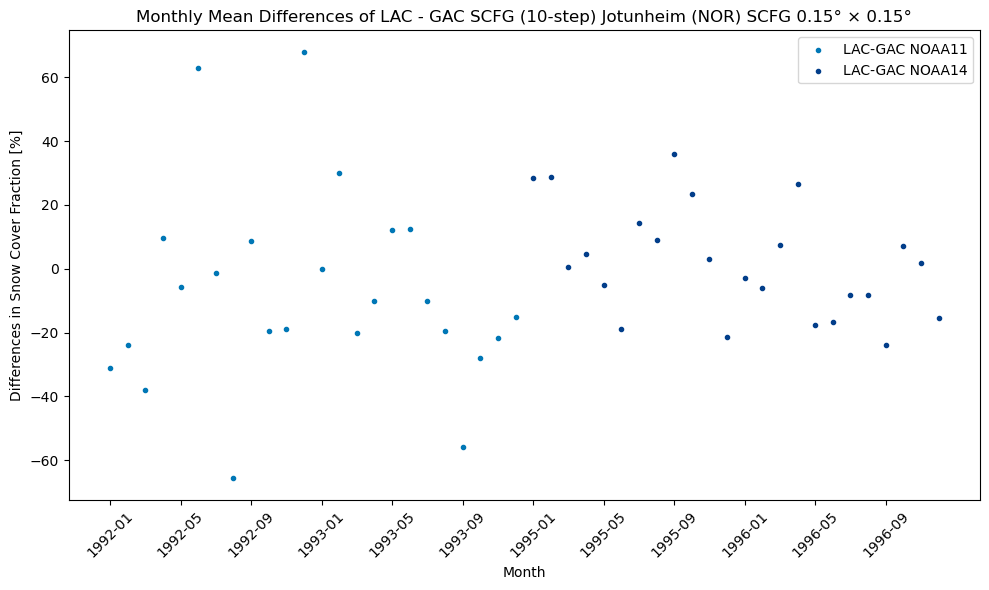


Top 10 NOAA11 monthly LAC-GAC differences for Jotunheim (NOR):
1992-12: 68.00
1992-08: -65.71
1992-06: 62.86
1993-09: -55.83
1992-03: -37.92
1992-01: -31.00
1993-02: 30.00
1993-10: -27.95
1992-02: -24.00
1993-11: -21.83

Top 10 NOAA14 monthly LAC-GAC differences for Jotunheim (NOR):
1995-09: 36.00
1995-02: 28.75
1995-01: 28.33
1996-04: 26.57
1996-09: -23.86
1995-10: 23.33
1995-12: -21.54
1995-06: -18.75
1996-05: -17.50
1996-06: -16.67


/tmp/ipykernel_292123/1139586768.py:16: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  month = date.to_period('M') if hasattr(date, 'to_period') else pd.to_datetime(date).to_period('M')


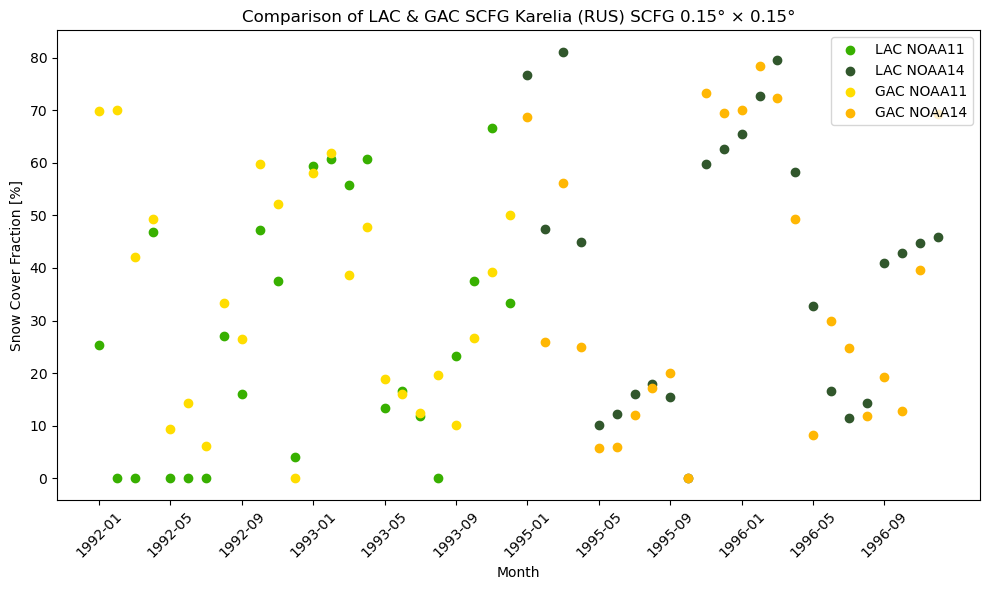

/tmp/ipykernel_292123/4266116972.py:15: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  month = pd.to_datetime(date).to_period('M')


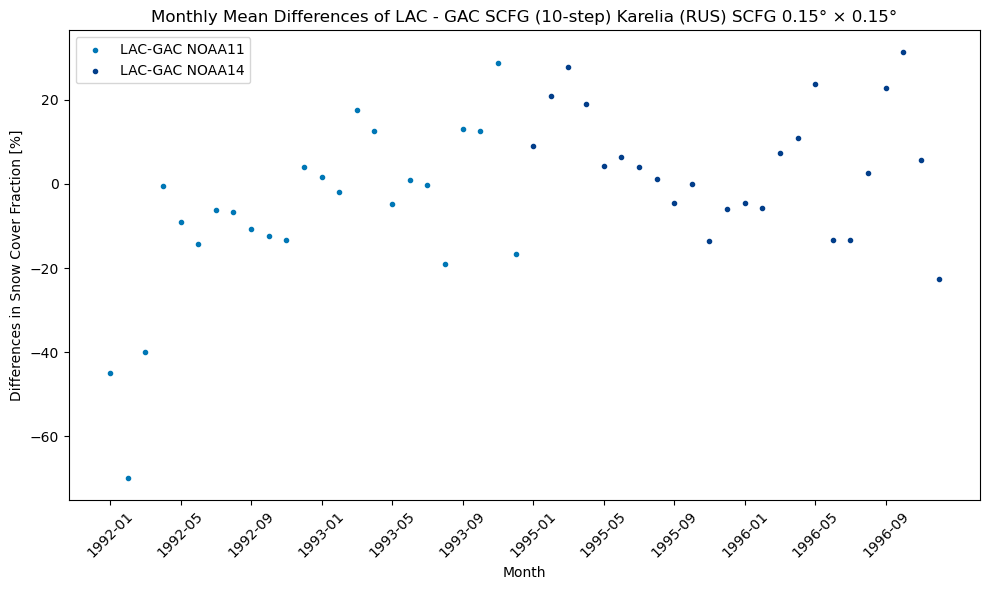


Top 10 NOAA11 monthly LAC-GAC differences for Karelia (RUS):
1992-02: -70.00
1992-01: -44.88
1992-03: -40.00
1993-11: 28.67
1993-08: -19.09
1993-03: 17.55
1993-12: -16.67
1992-06: -14.29
1992-11: -13.41
1993-09: 12.94

Top 10 NOAA14 monthly LAC-GAC differences for Karelia (RUS):
1996-10: 31.43
1995-03: 27.81
1996-05: 23.67
1996-09: 22.91
1996-12: -22.65
1995-02: 21.00
1995-04: 19.00
1995-11: -13.50
1996-07: -13.40
1996-06: -13.33


/tmp/ipykernel_292123/1139586768.py:16: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  month = date.to_period('M') if hasattr(date, 'to_period') else pd.to_datetime(date).to_period('M')


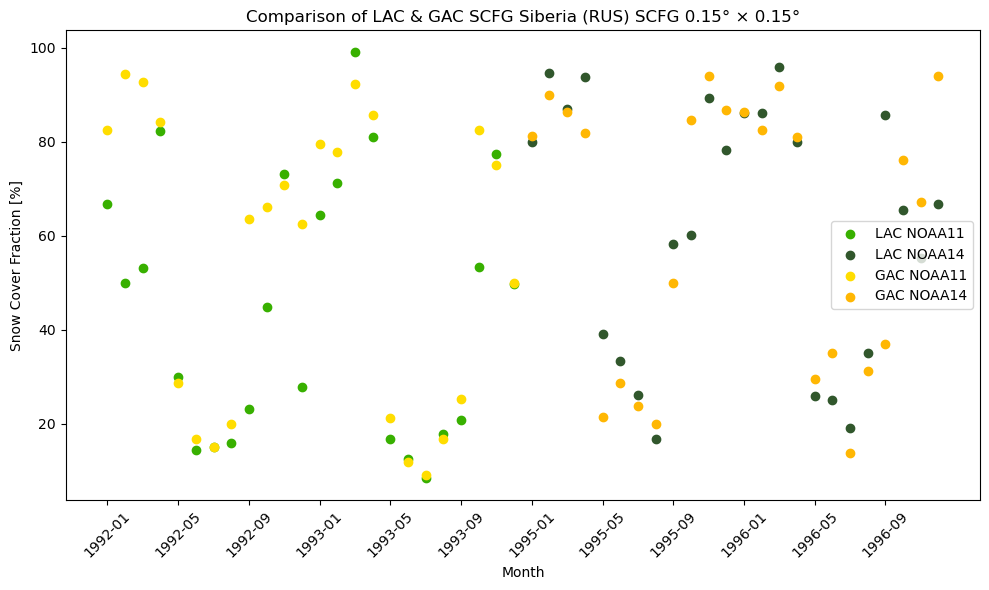

/tmp/ipykernel_292123/4266116972.py:15: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  month = pd.to_datetime(date).to_period('M')


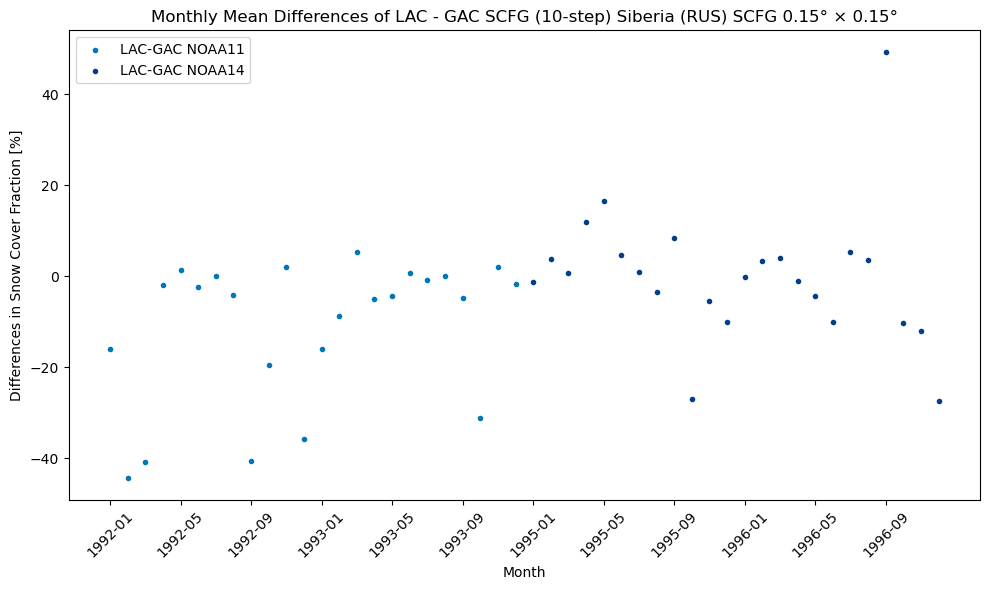


Top 10 NOAA11 monthly LAC-GAC differences for Siberia (RUS):
1992-02: -44.44
1992-03: -40.86
1992-09: -40.56
1992-12: -35.83
1993-10: -31.14
1992-10: -19.55
1993-01: -16.06
1992-01: -15.94
1993-02: -8.69
1993-03: 5.38

Top 10 NOAA14 monthly LAC-GAC differences for Siberia (RUS):
1996-09: 49.35
1996-12: -27.45
1995-10: -26.92
1995-05: 16.43
1996-11: -12.03
1995-04: 11.93
1996-10: -10.38
1995-12: -10.00
1996-06: -10.00
1995-09: 8.33


In [11]:
date_range = start_date.replace('-', '') + '_' + end_date.replace('-', '') # Create string for folder name
# Create dirs
if not os.path.isdir('plots/'):
    os.makedirs('plots/')
if not os.path.isdir(f'plots/{date_range}/'):
    os.makedirs(f'plots/{date_range}/')

for region, coords in get_coords().items():
    csv_path = get_csv_path(path_to_csv_files, region)
    csv_file = read_csv(csv_path)
    filtered_data = filter_dates(csv_file, start_date, end_date)
    # Plot
    if fullrange_comparison:
        plot_comparison(var_dict = csv_file, csv_path = csv_path, plot_category = plot_category, date_range=date_range)
    else:
        plot_comparison(var_dict = filtered_data, csv_path = csv_path, plot_category = plot_category, date_range=date_range)
    
    if fullrange_differences:
        plot_difference(var_dict = csv_file, csv_path = csv_path, date_range = date_range)
    else:
        plot_difference(var_dict = filtered_data, csv_path = csv_path, date_range = date_range)

### Create single plots

In [ ]:
### DEFINE PLOT PARAMETERS ###

# Csv file name
csv_filename = 'rus_Karelia_values_20260817_123456'

# Range of Plot date
start_date = '01-01-1992'
end_date = '31-12-1996'

# Comparision plots
plot_category = False               # Categorize SCF values (10-stages)
fullrange_comparison = False        # ignores start_date and end_date for comparison plots

# Differences plots
fullrange_differences = True        # ignores start_date and end_date for difference plots

In [13]:
# Define the CSV file path
csv_path = get_csv_file(csv_filename)

In [14]:
csv_path2 = 'csv/SCFG015x015_degree/rus_Karelia_values_20260817_123456.csv'

In [15]:
# Read csv file
new_dict = read_csv(csv_path2)

In [16]:
# Filter data by defined time span
filtered_data = filter_dates(new_dict, start_date, end_date)

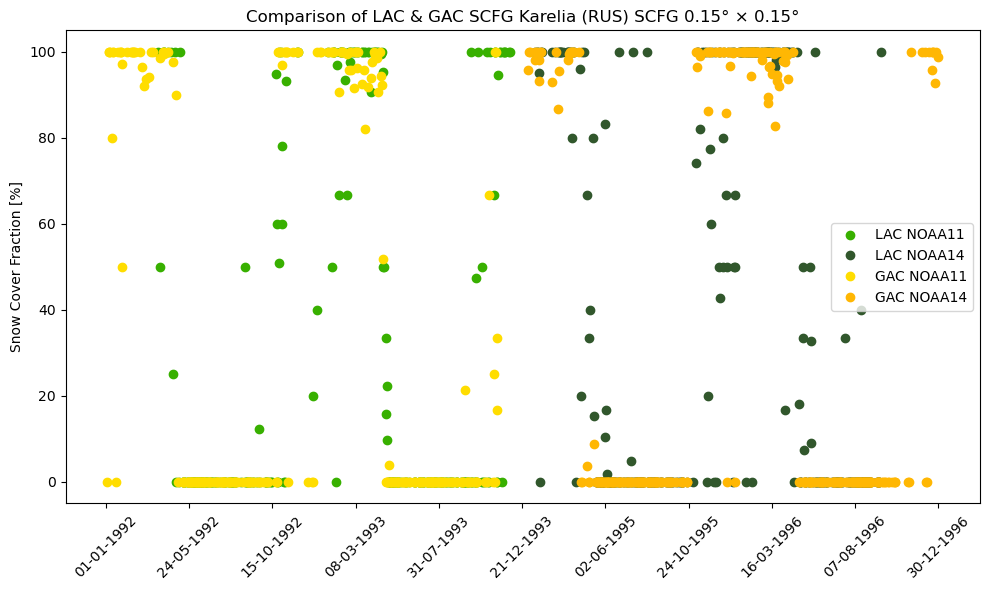

In [17]:
# Plot
if fullrange_comparison:
    plot_comparison(var_dict = new_dict, csv_path = csv_path, plot_category = plot_category, date_range=date_range)
else:
    plot_comparison(var_dict = filtered_data, csv_path = csv_path, plot_category = plot_category, date_range=date_range)

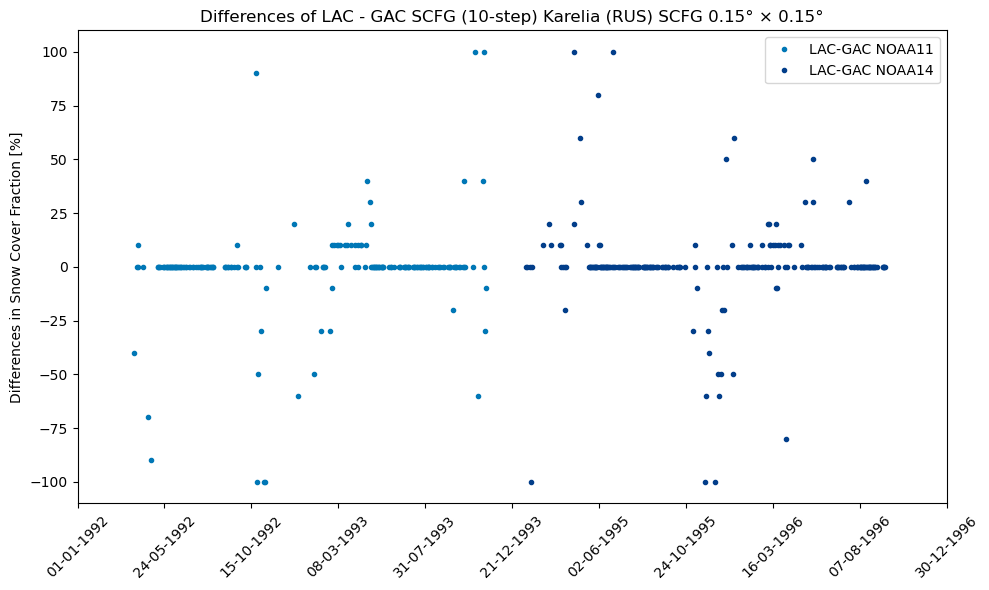


Top 10 NOAA11 LAC-GAC differences for Karelia (RUS):
25-10-1992: -100.0
05-11-1992: -100.0
06-11-1992: -100.0
21-10-1993: 100.0
04-11-1993: 100.0
01-05-1992: -90.0
22-10-1992: 90.0
26-04-1992: -70.0
01-01-1993: -60.0
25-10-1993: -60.0

Top 10 NOAA14 LAC-GAC differences for Karelia (RUS):
09-02-1995: -100.0
22-04-1995: 100.0
25-06-1995: 100.0
24-11-1995: -100.0
11-12-1995: -100.0
01-06-1995: 80.0
07-04-1996: -80.0
02-05-1995: 60.0
26-11-1995: -60.0
18-12-1995: -60.0


In [18]:
# Plot
if fullrange_differences:
    plot_difference(var_dict = new_dict, csv_path = csv_path, date_range=date_range)
else:
    plot_difference(var_dict = filtered_data, csv_path = csv_path, date_range=date_range)

In [36]:
### DEFINE PLOT PARAMETERS ###

# Csv file name
csv_filename = 'rus_Siberia_values_20260817_123456'

# Range of Plot date
start_date = '01-01-1992'
end_date = '31-12-1996'

# Comparision plots
plot_category = False               # Categorize SCF values (10-stages)
fullrange_comparison = False        # ignores start_date and end_date for comparison plots

# Differences plots
fullrange_differences = True        # ignores start_date and end_date for difference plots

In [39]:
# Define the CSV file path
csv_path = get_csv_file(csv_filename)
csv_path2 = 'csv/SCFG015x015_degree/rus_Siberia_values_20260817_123456.csv'
# Read csv file
new_dict = read_csv(csv_path2)
# Filter data by defined time span
filtered_data = filter_dates(new_dict, start_date, end_date)

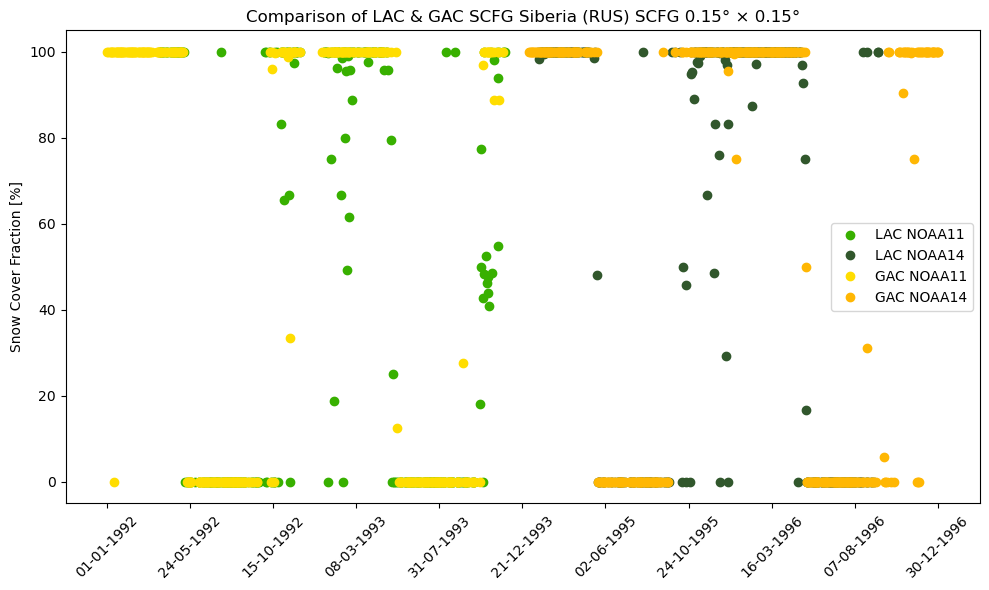

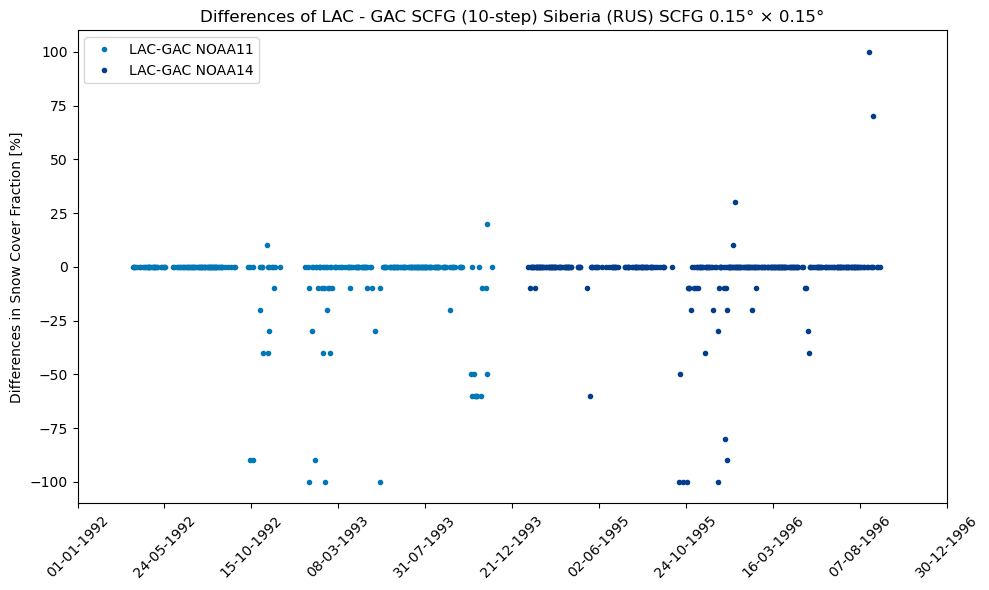


Top 10 NOAA11 LAC-GAC differences for Siberia (RUS):
18-01-1993: -100.0
14-02-1993: -100.0
16-05-1993: -100.0
13-10-1992: -90.0
18-10-1992: -90.0
29-01-1993: -90.0
15-10-1993: -60.0
20-10-1993: -60.0
22-10-1993: -60.0
23-10-1993: -60.0

Top 10 NOAA14 LAC-GAC differences for Siberia (RUS):
13-10-1995: -100.0
19-10-1995: -100.0
26-10-1995: -100.0
17-12-1995: -100.0
22-08-1996: 100.0
31-12-1995: -90.0
28-12-1995: -80.0
29-08-1996: 70.0
18-05-1995: -60.0
15-10-1995: -50.0


In [40]:
# Plot
if fullrange_comparison:
    plot_comparison(var_dict = new_dict, csv_path = csv_path, plot_category = plot_category, date_range=date_range)
else:
    plot_comparison(var_dict = filtered_data, csv_path = csv_path, plot_category = plot_category, date_range=date_range)

    # Plot
if fullrange_differences:
    plot_difference(var_dict = new_dict, csv_path = csv_path, date_range=date_range)
else:
    plot_difference(var_dict = filtered_data, csv_path = csv_path, date_range=date_range)

In [42]:
### DEFINE PLOT PARAMETERS ###

# Csv file name
csv_filename = 'nor_Jotunheim_values_20260817_123456'

# Range of Plot date
start_date = '01-01-1992'
end_date = '31-12-1996'

# Comparision plots
plot_category = False               # Categorize SCF values (10-stages)
fullrange_comparison = False        # ignores start_date and end_date for comparison plots

# Differences plots
fullrange_differences = True        # ignores start_date and end_date for difference plots

In [43]:
# Define the CSV file path
csv_path = get_csv_file(csv_filename)
csv_path2 = 'csv/SCFG015x015_degree/nor_Jotunheim_values_20260817_123456.csv'
# Read csv file
new_dict = read_csv(csv_path2)
# Filter data by defined time span
filtered_data = filter_dates(new_dict, start_date, end_date)

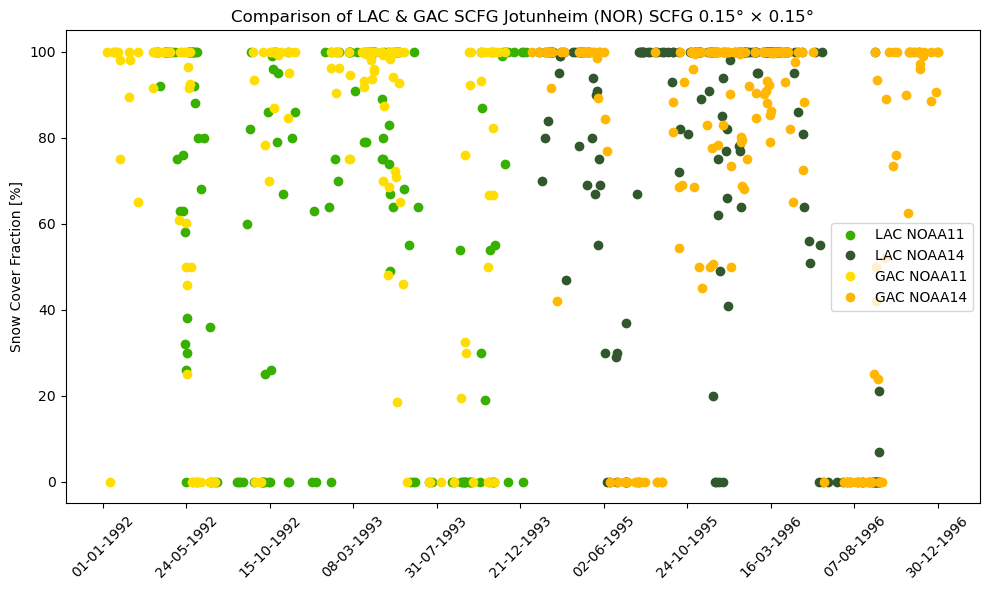

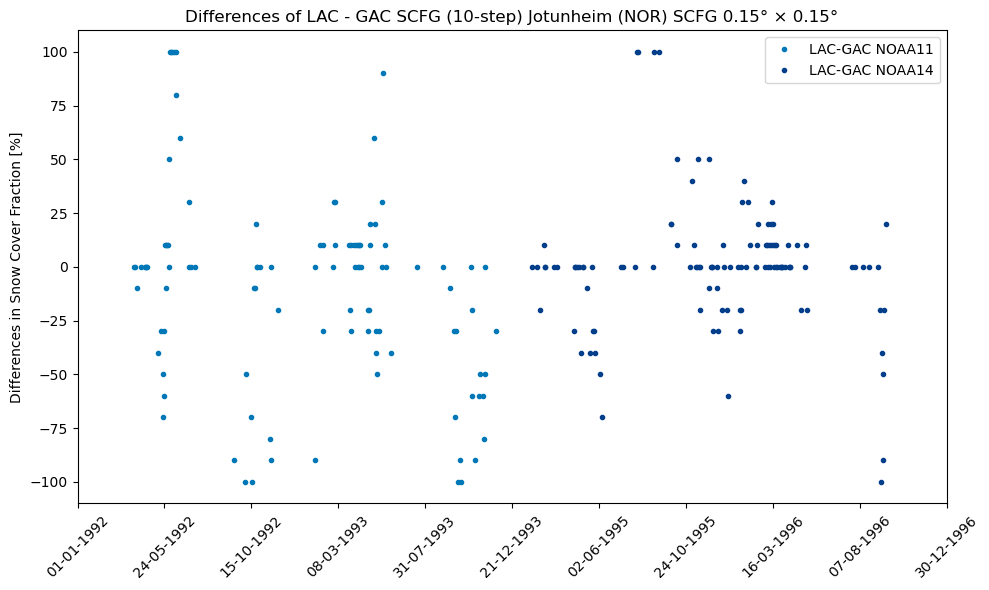


Top 10 NOAA11 LAC-GAC differences for Jotunheim (NOR):
02-06-1992: 100.0
04-06-1992: 100.0
05-06-1992: 100.0
09-06-1992: 100.0
12-06-1992: 100.0
04-10-1992: -100.0
16-10-1992: -100.0
23-09-1993: -100.0
27-09-1993: -100.0
17-09-1992: -90.0

Top 10 NOAA14 LAC-GAC differences for Jotunheim (NOR):
04-08-1995: 100.0
05-08-1995: 100.0
01-09-1995: 100.0
10-09-1995: 100.0
12-09-1996: -100.0
15-09-1996: -90.0
07-06-1995: -70.0
02-01-1996: -60.0
04-06-1995: -50.0
10-10-1995: 50.0


In [44]:
# Plot
if fullrange_comparison:
    plot_comparison(var_dict = new_dict, csv_path = csv_path, plot_category = plot_category, date_range=date_range)
else:
    plot_comparison(var_dict = filtered_data, csv_path = csv_path, plot_category = plot_category, date_range=date_range)

    # Plot
if fullrange_differences:
    plot_difference(var_dict = new_dict, csv_path = csv_path, date_range=date_range)
else:
    plot_difference(var_dict = filtered_data, csv_path = csv_path, date_range=date_range)